# Market Signal Analysis

This notebook performs a simple market time-series analysis using sample price data.

The goal is to demonstrate basic data loading, timestamp cleaning, feature engineering, and visual inspection of price and volatility.


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys

sys.path.append(str(Path.cwd().parent / "src"))

from metrics import (
    calculate_returns,
    calculate_max_drawdown,
    calculate_win_rate,
    calculate_sharpe_like,
)
from signals import momentum_signal

data_path = Path("../data/sample_prices.csv")

df = pd.read_csv(data_path)

df.head()

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.head()

df.info()

rolling_window = 24

df["return"] = calculate_returns(df["close"])
df["rolling_mean"] = df["close"].rolling(window=rolling_window).mean()
df["rolling_volatility"] = df["return"].rolling(window=rolling_window).std()

df.head(30)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2024-01-01 00:00:00 to 2024-01-02 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


,close,return,rolling_mean,rolling_volatility
timestamp,,,,
2024-01-01 00:00:00,42100.5,NaN,NaN,NaN
2024-01-01 01:00:00,42210.2,0.002606,NaN,NaN
2024-01-01 02:00:00,42080.7,-0.003068,NaN,NaN
2024-01-01 03:00:00,42350.1,0.006402,NaN,NaN
2024-01-01 04:00:00,42420.3,0.001658,NaN,NaN
2024-01-01 05:00:00,42310.8,-0.002581,NaN,NaN
2024-01-01 06:00:00,42540.6,0.005431,NaN,NaN
2024-01-01 07:00:00,42620.4,0.001876,NaN,NaN
2024-01-01 08:00:00,42490.2,-0.003055,NaN,NaN


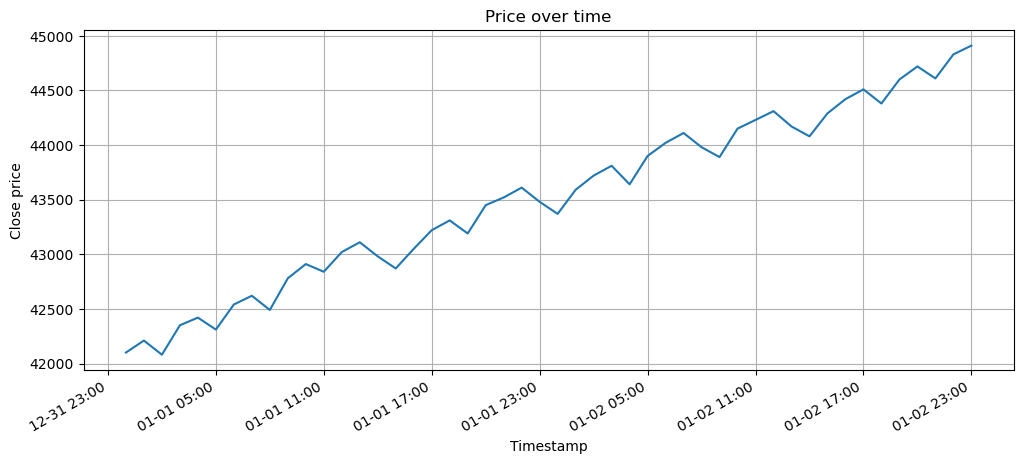

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["close"], linewidth=1.5)

ax.set_title("Price over time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Close price")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


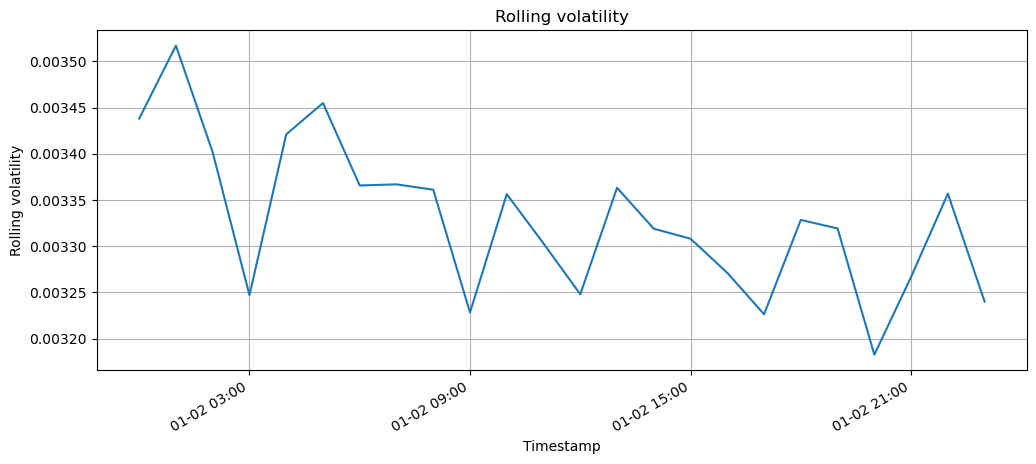

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["rolling_volatility"], linewidth=1.5)

ax.set_title("Rolling volatility")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rolling volatility")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Initial observations

The dataset is sorted by timestamp and indexed as a time series.  
The return column measures percentage price changes between consecutive observations.  
Rolling volatility is calculated as the rolling standard deviation of returns.

At this stage, the notebook only performs basic exploratory analysis. No trading signal or backtest is included yet.
